In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# loading the dataset
df = pd.read_csv('datasets/house_prices.csv')   
df.head()

,size,bedrooms,age,distance_to_city,price
0,1748.357077,4,42,11.560348,484600.725275
1,1430.867849,1,18,10.749658,372212.902742
2,1823.844269,3,68,6.900329,528428.642933
3,2261.514928,5,50,22.036888,467060.791410
4,1382.923313,3,10,10.862971,369456.485277


In [3]:
correlation = df.corr()
correlation.head()

,size,bedrooms,age,distance_to_city,price
size,1.000000,-0.028081,-0.017331,-0.029103,0.932885
bedrooms,-0.028081,1.000000,0.039730,-0.036497,0.081365
age,-0.017331,0.039730,1.000000,-0.052364,-0.030761
distance_to_city,-0.029103,-0.036497,-0.052364,1.000000,-0.348283
price,0.932885,0.081365,-0.030761,-0.348283,1.000000


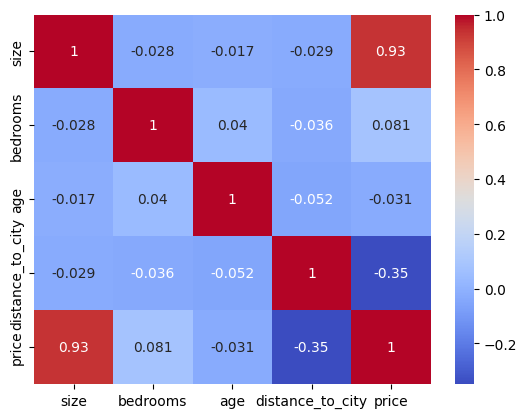

In [4]:
# creating a heatmap
sns.heatmap(correlation, annot = True, cmap = 'coolwarm')
# other options for cmap are 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
plt.show()

In [5]:
x = df.iloc[:,:-1] 
y = df["price"]

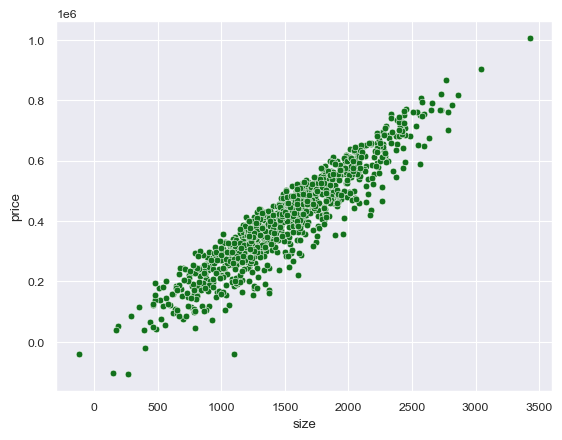

In [6]:
# relationship between the size and price
custom_palette = sns.color_palette([ '#12711C', '#8C0800', '#591E71', '#B8850A', '#006374'])
sns.set_theme(context='paper', style='darkgrid', palette=custom_palette)
sns.despine()
sns.scatterplot(x = "size", y = "price", data = df)
plt.show()

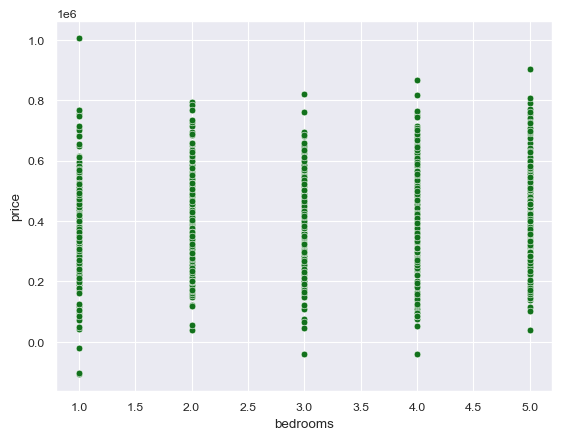

In [7]:
sns.scatterplot(x = "bedrooms", y = "price", data = df)
plt.show()

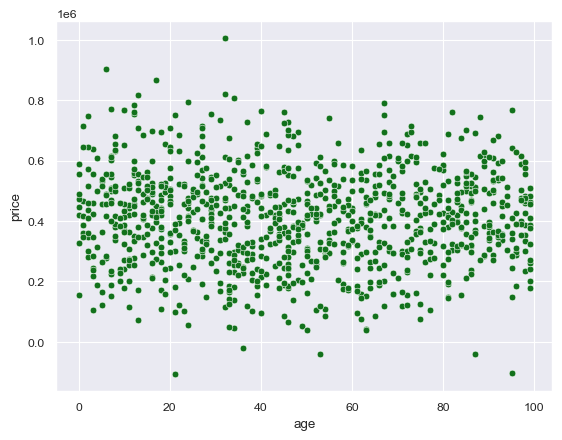

In [8]:
# 'size', 'bedrooms', 'age', 'distance_to_city'
# relationship between the age and price
sns.scatterplot(x = "age", y = "price", data = df)
plt.show()

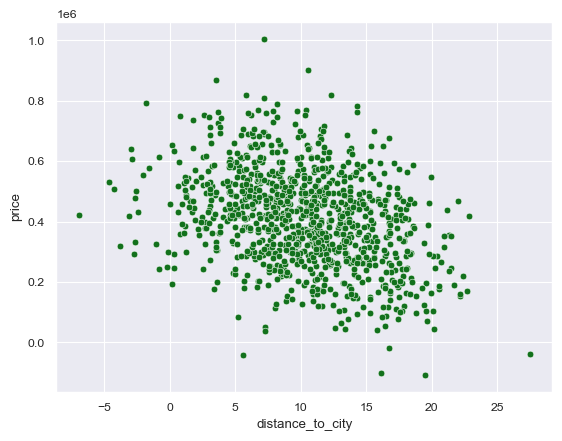

In [9]:
# relationship between the distance to city and price   
sns.scatterplot(x = "distance_to_city", y = "price", data = df)
plt.show()

In [10]:
pf = PolynomialFeatures(degree = 2)
pf.fit(x)
x = pf.transform(x)

In [11]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [12]:
# applying regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [13]:
# checking the score
print(lr.score(x_test, y_test)*100)

99.52418164972225


In [14]:
# predicting the values
input_data = np.array([[1748.357077,4,42,11.560348]])

# Transform the input data using the same PolynomialFeatures transformation
pf = PolynomialFeatures(degree=2)
input_data_transformed = pf.fit_transform(input_data)

# make prediciton
prediction = lr.predict(input_data_transformed)
print(prediction)


[488664.93669937]
